**INSTALAÇÃO E IMPORTS**

In [ ]:
'''Se estiver usando colab instale as bibliotecas abaixo com o comando !pip install <nome_da_biblioteca1> <nome_da_biblioteca2> <nome_da_biblioteca3>...'''

#Importanto bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**LEITURA DO ARQUIVO E CRIAÇAO DO DF**

*Lembrar de copiar no caminho do arquivo csv na pasta base_dados


In [4]:
df = pd.read_csv(r'C:\Users\Pichau\Tecnico-IA\ml_stat\bases_dados\base_imoveis.csv')

**EDA - ANÁLISE EXPLORATÓRIA DOS DADOS**

In [5]:
df.info()
df.shape # olhando as dimensões da base
df.head() #lista as colunas e 5 linhas iniciais (visualiza a base)

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_imovel      5500 non-null   str    
 1   localidade     5210 non-null   str    
 2   tipo           5200 non-null   str    
 3   area_m2        5216 non-null   float64
 4   quartos        5156 non-null   float64
 5   banheiros      5182 non-null   float64
 6   vagas_garagem  5181 non-null   float64
 7   idade_anos     5180 non-null   float64
 8   preco_venda    5173 non-null   float64
dtypes: float64(6), str(3)
memory usage: 386.8 KB


,id_imovel,localidade,tipo,area_m2,quartos,banheiros,vagas_garagem,idade_anos,preco_venda
0,IMV-10000,Candangolândia,Apartamento,152.0,2.0,2.0,2.0,24.0,468757.0
1,IMV-10001,Riacho Fundo,Casa,126.0,4.0,5.0,2.0,30.0,366019.0
2,IMV-10002,Riacho Fundo,Casa,587.0,4.0,4.0,4.0,36.0,1777368.0
3,IMV-10003,Gama,Apartamento,78.0,3.0,2.0,1.0,14.0,262673.0
4,IMV-10004,Cabeceira Grande,Casa,255.0,NaN,4.0,2.0,3.0,374877.0


**RESUMO ESTATÍSTICO**
Percepção inicial do comportamento dos dados

In [ ]:
df.describe()

**Separando categoricos e numéricos para o preprocessamento**

Fase de tratamento dos dados para inserir no 
- Definição das variáveis independentes(features)
- Definição da variável dependente (target)
- Aplicando tratamento de nulos para features pela mediana e moda
- Aplicando tratamento de nulos (drop) para o target



In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # O pipeline garante que as mesmas transformações utilizadas no treinamento sejam aplicadas aos novos imóveis posteriormente.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

features = [
    "localidade",
    "tipo",
    "area_m2",
    "quartos",
    "banheiros",
    "vagas_garagem",
    "idade_anos"
]

target = "preco_venda"

numeric_features = [
    "area_m2",
    "quartos",
    "banheiros",
    "vagas_garagem",
    "idade_anos"
]

categorical_features = [
    "localidade",
    "tipo"
]

df = df.dropna(subset=["preco_venda"]).copy() #Dropando nulos da variavel y

#Tratamento numerico
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")) # vamos usar a mediana para tratar os nulos numéricos
    ]
)

#tratamento categorico
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")), #aqui usamos a moda para imputar o mais frequente p/ substituir nulos
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

X = df[features]
y = df[target]

**Percentual de treinamento**
- 0.20 é o que o modelo vai prever
- Os demais 0.8 o modelo vai treinar

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Preprocessamento**

In [9]:
#Juntanto todo o processo
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**Aplicacação do método de regressão linear**

In [10]:
#Algoritimo de RL
from sklearn.linear_model import LinearRegression

modelo_linear = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

modelo_linear.fit(X_train, y_train)
#Agora com o que foi aprendido, vamos prever o preço de venda dos imóveis do conjunto de teste (X_test) e armazenar os resultados na variável y_pred_linear.
y_pred_linear = modelo_linear.predict(X_test) #comente esta linha se quiser ver o resultado do modelo, ou execute uma célula abaixo para ver o resultado do modelo.

**Indicadores de avaliação do modelo**\
MAE,RMSE,R²

In [11]:
from sklearn.metrics import ( mean_absolute_error, mean_squared_error, r2_score )
mae_linear = mean_absolute_error( y_test, y_pred_linear )
rmse_linear = np.sqrt( mean_squared_error( y_test, y_pred_linear ) )
r2_linear = r2_score( y_test, y_pred_linear )

print(f"R²: {r2_linear:.4f}")
print(f"MAE : R$ {mae_linear:,.2f}") 
print(f"RMSE: R$ {rmse_linear:,.2f}") 
print(f"R² : {r2_linear:.4f}")

R²: 0.8288
MAE : R$ 202,419.53
RMSE: R$ 329,888.56
R² : 0.8288


**Gráfico de Dispersão**

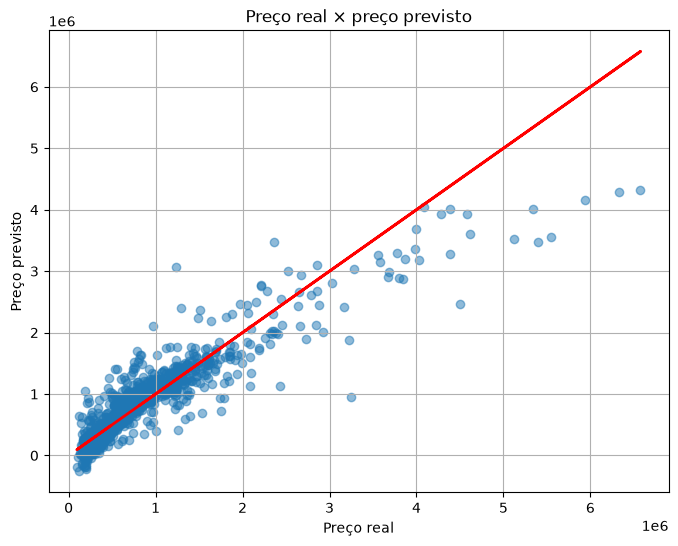

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter( y_test, y_pred_linear, alpha=0.5 )
plt.plot(y_test, y_test, color='red', linewidth=2)  # Linha de referência
plt.xlabel("Preço real") 
plt.ylabel("Preço previsto") 
plt.title("Preço real × preço previsto") 
plt.grid()
plt.show()

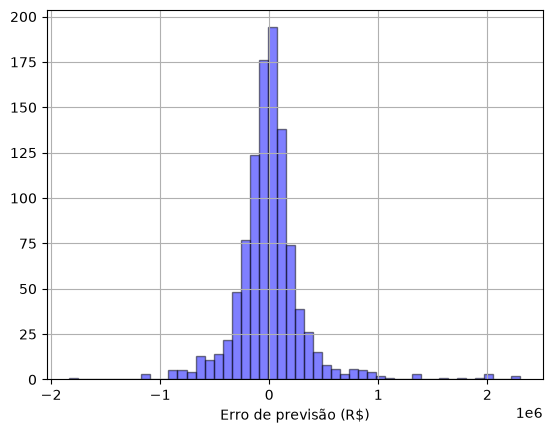

In [17]:
plt.hist( y_test - y_pred_linear, bins=50, alpha=0.5, color='blue', edgecolor='black')
plt.xlabel("Erro de previsão (R$)")
plt.grid()
plt.show()

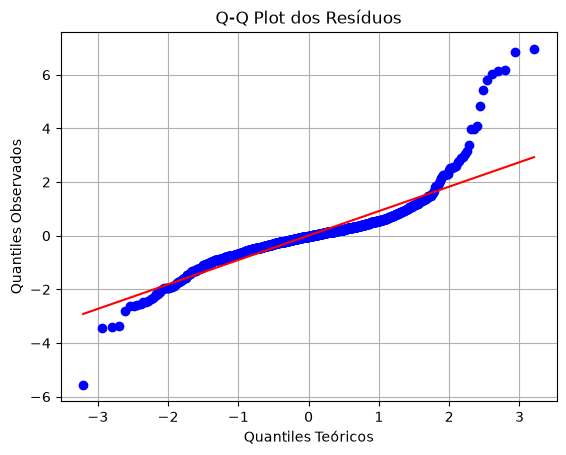

In [20]:
# Q-Q plot residuos
import scipy.stats as stats

z_escore_residuos = (y_test - y_pred_linear) / np.std(y_test - y_pred_linear, ddof=1)

stats.probplot(z_escore_residuos, dist="norm", plot=plt)
plt.title("Q-Q Plot dos Resíduos")
plt.xlabel("Quantiles Teóricos")
plt.ylabel("Quantiles Observados")
plt.grid()
plt.show()

**Questões:**

 Considerando que MAE é o erro médio, RMSE é penaliza mais esses erros,
- Qual é a intepretação de MAE?

R: O erro médio absoluto do nosso modelo foi de R$ 202,419.53 reais.

- Qual é a interpretação de RMSE?

R: Com base no RMSE, podemos dizer que a média de variação em torno dos valores previstos pelo nosso modelo é de R$ 329,888.56.

- Qual é a interpretação de R²

R: A interpretação do R² seria que o nosso modelo acerta 82,88% mais do apenas chutar a média dos dados.

- É correto afirmar que o modelo acerta 82% dos preços? Justifique

R: Quando calculamos o R² estamos calculando uma fração, onde o valor de cima são as observações individuais menos o valor previsto pelo nosso modelo e o valor de baixo são 
as observações individuais menos a média dos dados. Sendo assim, estamos calculando o quanto o nosso modelo é melhor do que a média para prever os dados que temos. Onde caso o valor
seja menor que 1, nosso modelo é melhor que a média, se for maior que 1, a média é melhor que nosso modelo, se for igual a 1, tanto a média quanto o nosso modelo erram a mesma quantidade.
Idealmente queremos que o valor seja sempre menor que 1 e o menor possível, pois ao subtrairmos essa fração de 1, que seria o 100%, teriamos o valor de R², que seria o quanto nosso modelo explica dos dados em relação a média.

- A diferença entre MAE e RMSE gera qual conclusão?

R: Que podemos ter alguns outliers no nossos dados. 

- Sob sua perpecpção o erro do modelo é aceitável para o mercado imobiliário?

R: Não, um erro de 200 a 300 mil reais em imóvel é um valor muito alto.


**Retorne ao gráfico e responda**
- Qual faixa de preço o modelo mais acertou

R: Entre 0 e 200 mil, que é a faixa de preço com maior concetração de imóveis.

- Qual faixa de preço houve erro e qual valor aproximado?

R: Há um aumento significativo nos erros a partir de 400 mil, onde o modelo começa a superestimar os valor dos imóveis.



In [33]:
# MAE e RMSE para faixa abaixo de 400 mil
mask = y_test < 400000
mae = mean_absolute_error(y_test[mask], y_pred_linear[mask])
rmse = np.sqrt(mean_squared_error(y_test[mask], y_pred_linear[mask]))
print(f"MAE para imóveis abaixo de R$ 400.000: R$ {mae:,.2f}")
print(f"RMSE para imóveis abaixo de R$ 400.000: R$ {rmse:,.2f}")

MAE para imóveis abaixo de R$ 400.000: R$ 143,498.55
RMSE para imóveis abaixo de R$ 400.000: R$ 193,562.48


In [34]:
# MAE e RMSE para faixa acima de 400 mil
mask = y_test > 400000
mae = mean_absolute_error(y_test[mask], y_pred_linear[mask])
rmse = np.sqrt(mean_squared_error(y_test[mask], y_pred_linear[mask]))
print(f"MAE para imóveis acima de R$ 400.000: R$ {mae:,.2f}")
print(f"RMSE para imóveis acima de R$ 400.000: R$ {rmse:,.2f}")

MAE para imóveis acima de R$ 400.000: R$ 220,986.75
RMSE para imóveis acima de R$ 400.000: R$ 362,372.03


**Comparando Resultados em tela**

- Execute a tabela diferença e compare valor real e o valor previsto(y_test -y_pred_linear)
- O que significam o valores positivos e negativos da coluna diferença?
R: O valores positivos são o quanto o quanto o modelo está prevendo abaixo do valor real e os valores negativos seriam o quanto a predição está acima do valor real.

In [29]:
#

tabela_diferenca = pd.DataFrame({
    "Real": y_test,
    "Previsto": y_pred_linear,
    "Diferença": y_test-y_pred_linear,
    "Erro bruto": abs(y_test-y_pred_linear),
})
print(tabela_diferenca.head(10))

           Real      Previsto      Diferença     Erro bruto
1680   480429.0  2.409247e+05  239504.257123  239504.257123
2133   285667.0  2.854097e+05     257.322805     257.322805
1313   764201.0  7.868861e+05  -22685.121715   22685.121715
3093  1165319.0  1.766441e+06 -601121.664470  601121.664470
4920   462161.0  4.579688e+05    4192.203525    4192.203525
1574   932577.0  8.358059e+05   96771.113265   96771.113265
1205   291801.0  3.335964e+05  -41795.367176   41795.367176
3993   918488.0  9.025459e+05   15942.051899   15942.051899
3262   968832.0  1.122755e+06 -153923.003452  153923.003452
561    425905.0  3.382975e+05   87607.502941   87607.502941


**Sugestões para discussão na próxima Aula**

- O que o gráfico abaixo sugere?

R: Que nosso modelo é adqueado para prever valores em uma faixa de preço de até 400 reais, porém, a partir desse valor ele começa a errar muito.

**Novos modelos e seus algoritmos**
Se possivel pesquise sobre arvore de decisão como é o princípio, qual a finidade e principais algoritimos e como elas podem ajudar uma imobiliária na classificação de imóveis ou clientes.

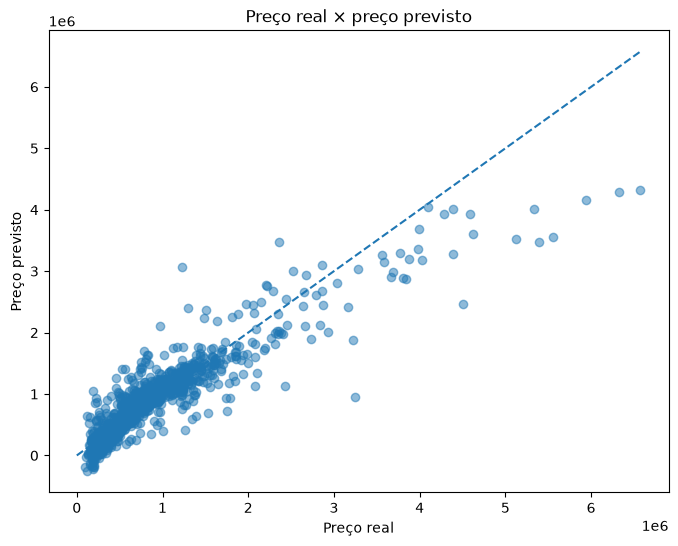

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.5
)

limite = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [0, limite],
    [0, limite],
    linestyle="--"
)

plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.title("Preço real × preço previsto")

plt.show()